In [ ]:
pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [7]:
df = pd.read_csv("/content/student_performance_dataset.csv")

# data cleaning, encoding and handling null values

df.drop_duplicates(inplace = True)

df.drop(['Student_ID', 'Gender'], axis = 1, inplace = True)

for col in df:
  if df[col].dtype == "object":
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


columns = [df.columns[i] for i in range(len(df.columns))]

imputer = SimpleImputer(strategy="most_frequent")
for col in columns:
  if col in df:
    if df[col].dtype!= "object" and df[col].isnull().sum() > 0:
      df.fillna(df[col].mean(), inplace=True)
    else:
      imputer.fit(df[[col]])
      df[col] = imputer.transform(df[[col]])

df.drop_duplicates(inplace = True)

df.dropna(inplace = True)

y = df['Pass_Fail']

df.drop('Pass_Fail', axis = 1, inplace = True)

smote = SMOTE()
x = df

x_resampled, y_resampled = smote.fit_resample(x, y)


x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size = 0.2, random_state = 42)

print(f"""

AFTER SMOTE


df.shape : {df.shape}
x_train : {x_train.shape}
x_test : {x_test.shape}
y_train : {y_train.shape}
y_test : {y_test.shape}
""")



AFTER SMOTE


df.shape : (500, 7)
x_train : (566, 7)
x_test : (142, 7)
y_train : (566,)
y_test : (142,)



In [8]:
print(df)

     Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
0                      31        68.267841                86   
1                      16        78.222927                73   
2                      21        87.525096                74   
3                      27        92.076483                99   
4                      37        98.655517                63   
..                    ...              ...               ...   
701                    21        69.858192                90   
702                    22        93.349688                76   
703                    14        84.658761                78   
705                    25        98.384969                75   
707                    22        80.404392                93   

     Parental_Education_Level  Internet_Access_at_Home  \
0                           1                        1   
1                           3                        0   
2                           3                        1   

In [16]:
print(y_train)

522    1
24     0
480    0
314    0
239    0
      ..
71     0
106    0
270    1
435    0
102    1
Name: Pass_Fail, Length: 566, dtype: int64


In [9]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix )

xgb_model = XGBClassifier(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    eval_metric='logloss',
    objective='binary:logistic'
)

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy_scores = accuracy_score(y_test, y_pred)
precision_scores = precision_score(y_test, y_pred, average='weighted')
recall_scores = recall_score(y_test, y_pred, average='weighted')
f1_scores = f1_score(y_test, y_pred, average='weighted') # caluculate metrics considering class imbalance

print(f"""
Accuracy Score : {accuracy_scores}
Precision Score : {precision_scores}
Recall Score : {recall_scores}
F1 Score : {f1_scores} """)


Accuracy Score : 1.0
Precision Score : 1.0
Recall Score : 1.0
F1 Score : 1.0 


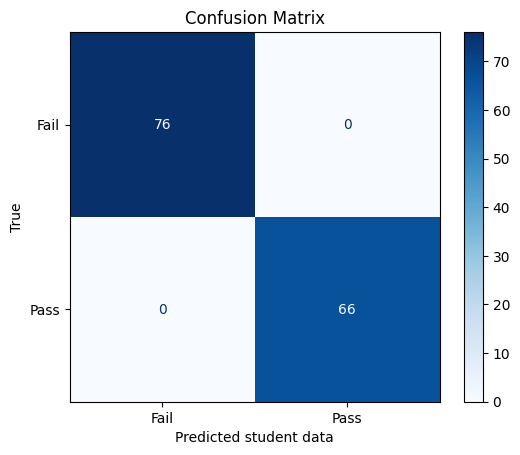

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass']) # Assuming binary classification for 'liked'
disp.plot(cmap=plt.cm.Blues)
plt.xlabel('Predicted student data')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [13]:
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00        76
        Pass       1.00      1.00      1.00        66

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



In [17]:
import joblib
if joblib.dump(xgb_model, 'student_performance_system.pkl'):
  print("model saved")

model saved
